# Part B: Predicting Housing Price

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')

## Importing and exploring housing_price_data.csv dataset

In [ ]:
data_path = Path('housing_price_data.csv')
if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at expected path: {data_path.resolve()}")

housepriceData = pd.read_csv(data_path)
print(f"Loaded {housepriceData.shape[0]} rows and {housepriceData.shape[1]} columns.")

In [ ]:
housepriceData.head()

,House ID,City,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Renovation Status,Price ($)
0,0,Chicago,742.0,4,2,3,furnished,1330000
1,1,Denver,896.0,4,4,4,furnished,1225000
2,2,Chicago,996.0,3,2,2,semi-furnished,1225000
3,3,Seattle,750.0,4,2,2,furnished,1221500
4,4,New York,742.0,4,1,2,furnished,1141000


In [ ]:
housepriceData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   House ID           545 non-null    int64  
 1   City               545 non-null    object 
 2   House Area (sqm)   545 non-null    float64
 3   No. of Bedrooms    545 non-null    int64  
 4   No. of Toilets     545 non-null    int64  
 5   Stories            545 non-null    int64  
 6   Renovation Status  545 non-null    object 
 7   Price ($)          545 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 34.2+ KB


In [ ]:
housepriceData.describe(include='all').T

,House ID,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Price ($)
count,545.00000,545.000000,545.000000,545.000000,545.000000,5.450000e+02
mean,272.00000,515.054128,2.965138,1.286239,1.805505,4.766729e+05
std,157.47222,217.014102,0.738064,0.502470,0.867492,1.870440e+05
min,0.00000,165.000000,1.000000,1.000000,1.000000,1.750000e+05
25%,136.00000,360.000000,2.000000,1.000000,1.000000,3.430000e+05
50%,272.00000,460.000000,3.000000,1.000000,2.000000,4.340000e+05
75%,408.00000,636.000000,3.000000,2.000000,2.000000,5.740000e+05
max,544.00000,1620.000000,6.000000,4.000000,4.000000,1.330000e+06


In [ ]:
housepriceData.isnull().sum()

House ID             0
City                 0
House Area (sqm)     0
No. of Bedrooms      0
No. of Toilets       0
Stories              0
Renovation Status    0
Price ($)            0
dtype: int64

## Feature engineering 

`Area per Bedroom` measures how much space is available for each bedroom.
This feature is useful because larger, more spacious homes tend to command higher prices.
Instead of only using total area or number of bedrooms separately, this ratio captures house spaciousness, which models typically find more informative when predicting house value.

In [ ]:
housepriceData["Area per Bedroom"] = (
    housepriceData["House Area (sqm)"] / housepriceData["No. of Bedrooms"]
)

housepriceData["Bathroom_Bedroom_Ratio"] = (
    housepriceData["No. of Toilets"] / housepriceData["No. of Bedrooms"]
)

housepriceData[["House Area (sqm)", "No. of Bedrooms", "No. of Toilets", "Area per Bedroom", "Bathroom_Bedroom_Ratio"]].head()

The `Bathroom Bedroom Ratio` indicates whether the house has enough bathrooms to support the number of bedrooms.
Houses with a higher bathroom-to-bedroom ratio are generally more comfortable and considered more premium, often leading to higher sale prices.
This feature helps the model understand home quality beyond simple counts.

In [8]:
housepriceData["Bathroom_Bedroom_Ratio"] = (
    housepriceData["No. of Toilets"] / housepriceData["No. of Bedrooms"]
)

In [9]:
housepriceData.head() # show dataset with new columns

,House ID,City,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Renovation Status,Price ($),Area per Bedroom,Bathroom_Bedroom_Ratio
0,0,Chicago,742.0,4,2,3,furnished,1330000,185.5,0.500000
1,1,Denver,896.0,4,4,4,furnished,1225000,224.0,1.000000
2,2,Chicago,996.0,3,2,2,semi-furnished,1225000,332.0,0.666667
3,3,Seattle,750.0,4,2,2,furnished,1221500,187.5,0.500000
4,4,New York,742.0,4,1,2,furnished,1141000,185.5,0.250000


## Data visualisation

The histogram shows that house prices in the dataset are right-skewed, with most properties priced between `$300,000 and $600,000`. A smaller number of houses exceed $1 million, creating a long tail on the right. This skewed distribution is common in real estate data because expensive houses are less frequent but have very high values.
Such skewness can negatively affect regression models by increasing the mean squared error (MSE) and reducing R², as the model struggles to fit these extreme high-value points.
This observation suggests that applying a log transformation to the Price column will help normalize the distribution and improve model performance.

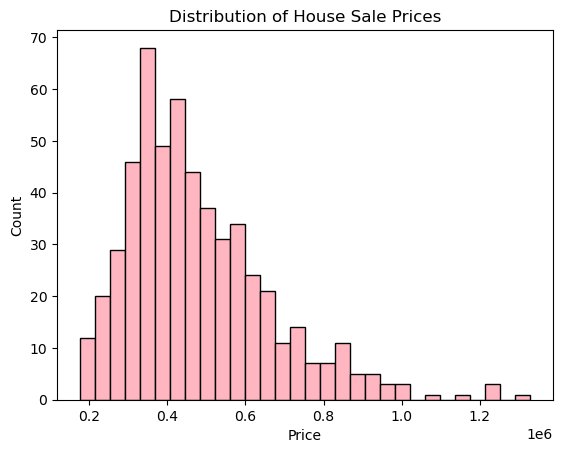

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(housepriceData['Price ($)'], bins=30, edgecolor='black', color='lightpink')
plt.title('Distribution of House Sale Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

This scatter plot shows the relationship between house size and sale price. There is an upward trend, where larger houses tend to have higher prices. Although there is some variation, the positive pattern suggests that house area is an im|portant predictor of price. This shows
that including House Areas a feature in the regression model is meaningful.

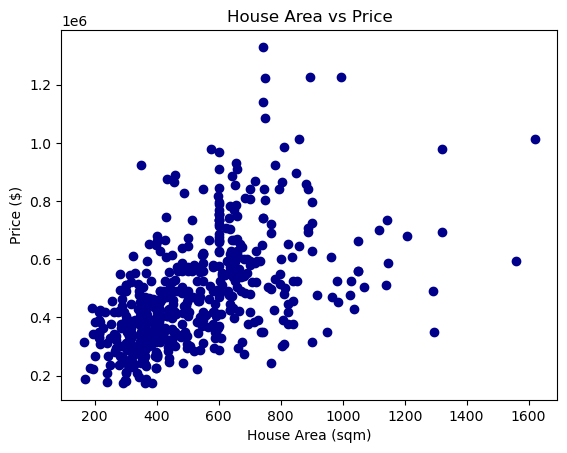

In [ ]:
plt.figure(figsize=(8, 4))
plt.scatter(housepriceData['House Area (sqm)'], housepriceData['Price ($)'], color='darkblue', alpha=0.7)
plt.xlabel('House Area (sqm)')
plt.ylabel('Price ($)')
plt.title('House Area vs Price')
plt.tight_layout()
plt.show()

## Transforming the target variable

The target distribution is right-skewed, which can make regression models overly sensitive to high-value properties. A log transformation compresses the range of values and usually improves stability, especially when the goal is to optimize error-based metrics such as MSE and RMSE.

The house prices in Price($) column is right-skewed, with only a few very expensive ones, and this creates a long tail on the right. Because regression models use squared error loss, extremely high prices produce very large errors, while small prices barely affect the model.

As a result, the model focuses heavily on predicting expensive houses correctly and becomes biased for lower-priced homes, often over-predicting them. This reduces overall accuracy and lowers the R² score.

Applying a log transformation compresses the range of values. Large prices shrink much more than small ones, reducing the influence of extreme outliers. This makes the distribution more balanced and helps the model learn patterns more effectively. 

After the log transform, the regression model becomes:

- less sensitive to outliers

- more stable

- better at predicting both low- and high-value houses

- more accurate overall

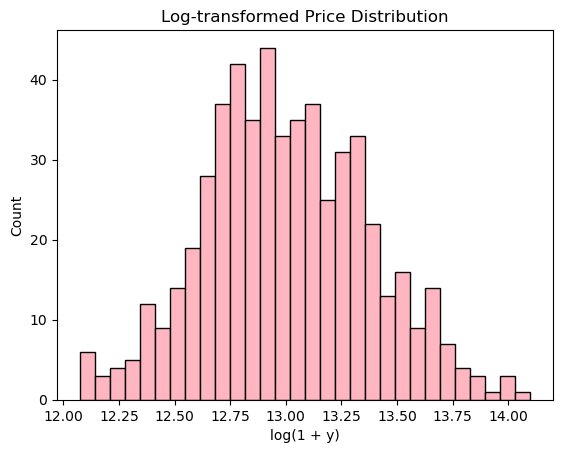

In [ ]:
y_log = np.log1p(housepriceData['Price ($)'])

plt.figure(figsize=(8, 4))
plt.hist(y_log, bins=30, edgecolor='black', color='lightpink')
plt.title('Log-transformed Price Distribution')
plt.xlabel('log(1 + Price)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

After applying the log transformation, the distribution becomes more symmetric and closer to a normal shape. This tends to improve learning stability for regression models and reduces the dominance of a few high-price outliers.

# Regression models

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
# Drop ID and target column 
X = housepriceData.drop(['House ID', 'Price ($)'], axis=1)
y_log = np.log1p(housepriceData['Price ($)'])

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

In [15]:
print(f'The shape of X is: {X.shape}.')
print(f'The shape of y is: {y_log.shape}.')

The shape of X is: (545, 8).
The shape of y is: (545,).


## Dummy model

A dummy regressor provides a baseline by predicting the average target value. It helps establish whether more sophisticated models add real predictive value rather than just fitting noise.

In [16]:
from sklearn.dummy import DummyRegressor

In [17]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

In [18]:
dummy = DummyRegressor(strategy="mean")

In [19]:
dummy.fit(X_train, y_train_log) # Train dummy model

,strategy,'mean'
,constant,None
,quantile,None


In [20]:
dummy_pred_log = dummy.predict(X_test) # Predictions (log scale)

In [21]:
dummy_pred = np.expm1(dummy_pred_log)  # Convert back to price scale

In [22]:
y_test = np.expm1(y_test_log) # Actual prices

In [23]:
dummy_MSE = mean_squared_error(y_test, dummy_pred)
dummy_RMSE = np.sqrt(dummy_MSE)
dummy_MAE = mean_absolute_error(y_test, dummy_pred)
dummy_R2 = r2_score(y_test, dummy_pred)

In [24]:
print(f'MSE test score is: {dummy_MSE}')
print(f'RSME test score is: {dummy_RMSE}')
print(f'MAE test score is: {dummy_MAE}')
print(f'r2 score is: {dummy_R2}')

MSE test score is: 54027835938.348335
RSME test score is: 232438.8864591042
MAE test score is: 175398.5462979951
r2 score is: -0.06889079199678338


## Model building (Linear regression)

A preprocessing pipeline is used so that scaling and encoding are applied consistently to both training and test data. This avoids data leakage and ensures that the model sees the same feature transformation logic during evaluation.

In [25]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [26]:
# Detect column types
numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns
categorical_cols = X_train.select_dtypes(include=['object','bool']).columns

In [27]:
# Preprocessor for mixed data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [28]:
# Full modeling pipeline
LinReg_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

In [29]:
LinReg_pipeline.fit(X_train, y_train_log) 

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
MyLinR_test_predictions_log = LinReg_pipeline.predict(X_test)

In [31]:
MyLinR_test_predictions = np.expm1(MyLinR_test_predictions_log)
y_test = np.expm1(y_test_log)

In [32]:
LinR_MSE_test = mean_squared_error(y_test, MyLinR_test_predictions)
LinR_RMSE_test = root_mean_squared_error(y_test, MyLinR_test_predictions)
LinR_MAE_test = mean_absolute_error(y_test, MyLinR_test_predictions)
LinR_r2_test =  r2_score(y_test, MyLinR_test_predictions)

In [33]:
print(f'MSE test score is: {LinR_MSE_test}')
print(f'RSME test score is: {LinR_RMSE_test}')
print(f'MAE test score is: {LinR_MAE_test}')
print(f'r2 score is: {LinR_r2_test}')

MSE test score is: 24790497775.224255
RSME test score is: 157449.984995948
MAE test score is: 115352.07382877728
r2 score is: 0.5095429172622896


## Linear regression model improvement

Lasso regression is a useful extension because it can shrink certain coefficients to zero, effectively performing automatic feature selection. This makes the model simpler and can reduce overfitting when some features are weak or redundant.

In [34]:
# Lasso pipeline
lassoLR_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', Lasso(max_iter=5000))
])

In [35]:
# Hyperparameter tuning
lassoLR_params = {
    'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10]
}

In [36]:
lassoLR_search = GridSearchCV(
    estimator=lassoLR_pipeline,
    param_grid=lassoLR_params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
)

In [37]:
lassoLR_search.fit(X_train, y_train_log)

,estimator,Pipeline(step..._iter=5000))])
,param_grid,"{'model__alpha': [0.0001, 0.001, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [38]:
best_lassoLR = lassoLR_search.best_estimator_

In [39]:
lassoLR_predictions_log = best_lassoLR.predict(X_test)

In [40]:
# Convert back to original price scale
lassoLR_predictions = np.expm1(lassoLR_predictions_log)

# Evaluate using real prices
y_test = np.expm1(y_test_log)

In [41]:
LassoLR_MSE = mean_squared_error(y_test, lassoLR_predictions)
LassoLR_RMSE = LassoLR_MSE ** 0.5
LassoLR_MAE = mean_absolute_error(y_test, lassoLR_predictions)
LassoLR_R2 = r2_score(y_test, lassoLR_predictions)

In [42]:
print(f'MSE test score is: {LassoLR_MSE}')
print(f'RSME test score is: {LassoLR_RMSE}')
print(f'MAE test score is: {LassoLR_MAE}')
print(f'r2 score is: {LassoLR_R2}')

MSE test score is: 24845604783.91046
RSME test score is: 157624.8863089533
MAE test score is: 114754.73831518336
r2 score is: 0.5084526760350381


In [43]:
print("===== BASE MODEL =====")
print(f"MSE test score is: {LinR_MSE_test}")
print(f"RMSE test score is: {LinR_RMSE_test}")
print(f"MAE test score is: {LinR_MAE_test}")
print(f"r2 score is: {LinR_r2_test}")

print("\n===== IMPROVED MODEL =====")
print(f"MSE test score is: {LassoLR_MSE}")
print(f"RMSE test score is: {LassoLR_RMSE}")
print(f"MAE test score is: {LassoLR_MAE}")
print(f"r2 score is: {LassoLR_R2}")

===== BASE MODEL =====
MSE test score is: 24790497775.224255
RMSE test score is: 157449.984995948
MAE test score is: 115352.07382877728
r2 score is: 0.5095429172622896

===== IMPROVED MODEL =====
MSE test score is: 24845604783.91046
RMSE test score is: 157624.8863089533
MAE test score is: 114754.73831518336
r2 score is: 0.5084526760350381


## Model building (Decision tree regressor)

Decision trees are useful because they can model nonlinear relationships without requiring manual transformations. They also make it easier to inspect which features are driving predictions, although they can be prone to overfitting if not constrained.

In [44]:
from sklearn.tree import DecisionTreeRegressor

In [45]:
DTR_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

In [46]:
DTR_pipeline.fit(X_train, y_train_log)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [47]:
DTR_predictions_log = DTR_pipeline.predict(X_test)

In [48]:
# Convert back to original price scale
DTR_predictions = np.expm1(DTR_predictions_log)

# Evaluate using REAL prices
y_test = np.expm1(y_test_log)

In [49]:
DTR_MSE_test = mean_squared_error(y_test, DTR_predictions)
DTR_RMSE_test = root_mean_squared_error(y_test, DTR_predictions)
DTR_MAE_test = mean_absolute_error(y_test, DTR_predictions)
DTR_r2_test =  r2_score(y_test, DTR_predictions)

In [50]:
print(f'MSE test score is: {DTR_MSE_test}')
print(f'RSME test score is: {DTR_RMSE_test}')
print(f'MAE test score is: {DTR_MAE_test}')
print(f'r2 score is: {DTR_r2_test}')

MSE test score is: 51002647658.27775
RSME test score is: 225837.65775060136
MAE test score is: 151791.7248664591
r2 score is: -0.009040238287507885


## DTR model improvement

The tuned decision tree reduces the chance of memorizing the training set by limiting complexity. Hyperparameter tuning helps balance bias and variance so the model generalizes better to unseen data.

In [51]:
DTR_param_grid = {
    'model__max_depth': [None, 2, 3, 4, 5, 6, 8, 10],
    'model__min_samples_split': [2, 4, 6, 8, 10],
    'model__min_samples_leaf': [1, 2, 3, 4, 5],
    'model__max_features': [None, 'sqrt', 'log2']
}

In [52]:
DTR_gridsearch = GridSearchCV(
    estimator=DTR_pipeline,
    param_grid=DTR_param_grid,
    cv=5,
    scoring='r2'
)

In [53]:
DTR_gridsearch.fit(X_train, y_train_log)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 2, ...], 'model__max_features': [None, 'sqrt', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 4, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [54]:
bestDTR = DTR_gridsearch.best_estimator_
DTR_improved_predictions_log = bestDTR.predict(X_test)

In [55]:
# Convert back to original price scale
DTR_improved_predictions = np.expm1(DTR_improved_predictions_log)

# Evaluate using REAL prices
y_test = np.expm1(y_test_log)

In [56]:
DTR_MSE_test_improved  = mean_squared_error(y_test, DTR_improved_predictions)
DTR_RMSE_test_improved = root_mean_squared_error(y_test, DTR_improved_predictions)
DTR_MAE_test_improved  = mean_absolute_error(y_test, DTR_improved_predictions)
DTR_r2_test_improved   = r2_score(y_test, DTR_improved_predictions)

In [57]:
print(f'Improved DTR MSE test score is:{DTR_MSE_test_improved}')
print(f'Improved DTR RMSE test score is:{DTR_RMSE_test_improved}')
print(f'Improved DTR MAE test score is:{DTR_MAE_test_improved}')
print(f'Improved DTR r2 score is: {DTR_r2_test_improved}')

Improved DTR MSE test score is:30181826719.81178
Improved DTR RMSE test score is:173729.1763631307
Improved DTR MAE test score is:125864.93363244267
Improved DTR r2 score is: 0.4028804577095647


In [58]:
print("===== BASE MODEL =====")
print(f"MSE test score is: {DTR_MSE_test}")
print(f"RMSE test score is: {DTR_RMSE_test}")
print(f"MAE test score is: {DTR_MAE_test}")
print(f"r2 score is: {DTR_r2_test}")

print("\n===== IMPROVED MODEL =====")
print(f"MSE test score is: {DTR_MSE_test_improved}")
print(f"RMSE test score is: {DTR_RMSE_test_improved}")
print(f"MAE test score is: {DTR_MAE_test_improved}")
print(f"r2 score is: {DTR_r2_test_improved}")

===== BASE MODEL =====
MSE test score is: 51002647658.27775
RMSE test score is: 225837.65775060136
MAE test score is: 151791.7248664591
r2 score is: -0.009040238287507885

===== IMPROVED MODEL =====
MSE test score is: 30181826719.81178
RMSE test score is: 173729.1763631307
MAE test score is: 125864.93363244267
r2 score is: 0.4028804577095647


## Model building (Gradient Boosting Regressor)

Gradient Boosting is a strong choice for structured tabular data because it builds trees sequentially to correct prior errors. It often performs well when the relationship between features and price is complex and nonlinear.

In [59]:
from sklearn.ensemble import GradientBoostingRegressor

In [60]:
gbr_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),             
    ('model', GradientBoostingRegressor(random_state=42))
])

In [61]:
gbr_pipeline.fit(X_train, y_train_log)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [62]:
gbr_predictions_log = gbr_pipeline.predict(X_test)

In [63]:
# Convert back to original price scale
gbr_predictions = np.expm1(gbr_predictions_log)

# Evaluate using REAL prices
y_test = np.expm1(y_test_log)

In [64]:
GBR_MSE = mean_squared_error(y_test, gbr_predictions)
GBR_RMSE = GBR_MSE ** 0.5
GBR_MAE = mean_absolute_error(y_test, gbr_predictions)
GBR_R2 = r2_score(y_test, gbr_predictions)

In [65]:
print(f'MSE test score is: {GBR_MSE}')
print(f'RSME test score is: {GBR_RMSE}')
print(f'MAE test score is: {GBR_MAE}')
print(f'r2 score is: {GBR_R2}')

MSE test score is: 26454826224.473248
RSME test score is: 162649.39663113802
MAE test score is: 116893.95470437602
r2 score is: 0.47661571735943675


## GBR model improvement

The tuned Gradient Boosting model further improves generalization by adjusting model complexity and learning behavior. This is a common approach when a base ensemble model is already strong but still benefits from regularization and tuning.

In [66]:
GBR_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', GradientBoostingRegressor())
])

In [67]:
GBR_params = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3, 4]
}

In [68]:
GBR_search = GridSearchCV(
    estimator=GBR_pipeline,
    param_grid=GBR_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

In [69]:
GBR_search.fit(X_train, y_train_log)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [100, 200]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [70]:
best_gbr = GBR_search.best_estimator_
GBR_preds_log = best_gbr.predict(X_test)

In [71]:
# Convert back to original price scale
GBR_preds = np.expm1(GBR_preds_log)

# 6. Evaluate using REAL prices
y_test = np.expm1(y_test_log)

In [72]:
GBR_improved_MSE = mean_squared_error(y_test, GBR_preds)
GBR_improved_RMSE = GBR_improved_MSE ** 0.5
GBR_improved_MAE = mean_absolute_error(y_test, GBR_preds)
GBR_improved_R2 = r2_score(y_test, GBR_preds)

In [73]:
print(f'Improved GBR MSE test score is:{GBR_improved_MSE}')
print(f'Improved GBR RMSE test score is:{GBR_improved_RMSE}')
print(f'Improved GBR MAE test score is:{GBR_improved_MAE}')
print(f'Improved GBR r2 score is:{GBR_improved_R2}')

Improved GBR MSE test score is:25296910002.843857
Improved GBR RMSE test score is:159050.02358642974
Improved GBR MAE test score is:115375.46791426482
Improved GBR r2 score is:0.4995240194542254


In [74]:
print("===== BASE MODEL =====")
print(f"MSE test score is: {GBR_MSE}")
print(f"RMSE test score is: {GBR_MSE}")
print(f"MAE test score is: {GBR_MAE}")
print(f"r2 score is: {GBR_R2}")

print("\n===== IMPROVED MODEL =====")
print(f"MSE test score is: {GBR_improved_MSE}")
print(f"RMSE test score is: {GBR_improved_RMSE}")
print(f"MAE test score is: {GBR_improved_MAE}")
print(f"r2 score is: {GBR_improved_R2}")

===== BASE MODEL =====
MSE test score is: 26454826224.473248
RMSE test score is: 26454826224.473248
MAE test score is: 116893.95470437602
r2 score is: 0.47661571735943675

===== IMPROVED MODEL =====
MSE test score is: 25296910002.843857
RMSE test score is: 159050.02358642974
MAE test score is: 115375.46791426482
r2 score is: 0.4995240194542254


## Conclusion

This project shows a practical machine learning workflow for housing price prediction, from raw data inspection to model comparison. The final takeaway is that the boosted ensemble model offers the strongest predictive performance among the tested approaches, while the preprocessing and transformation steps are essential for stable results.

### Key learning points

- Data quality and target distribution matter significantly in regression tasks.
- Feature engineering can improve the signal available to the model.
- Model selection should be based on validation performance, not only training performance.
- A simple baseline is necessary to judge whether a more complex model is genuinely better.

### Recommended next steps

- Add model interpretability analysis such as feature importance.
- Compare with additional algorithms such as Random Forest and XGBoost.
- Create a small deployment interface for interactive price estimation.